# PID

In [1]:
import os
os.getpid()

27898

# LAB

## Setup

In [3]:
import os, json, asyncio, warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

# # ── Configure Gemini API Key ──
# try:
#     from kaggle_secrets import UserSecretsClient
#     os.environ['GOOGLE_API_KEY'] = UserSecretsClient().get_secret('GOOGLE_API_KEY')
#     print('✅ API key loaded from Kaggle Secrets')
# except Exception:
#     pass
# # Or set directly: os.environ['GOOGLE_API_KEY'] = 'your-key'

# assert 'GOOGLE_API_KEY' in os.environ, '❌ Set GOOGLE_API_KEY as a Kaggle Secret!'

# ── ADK Imports ──
from google.adk.agents import LlmAgent
from google.adk.agents.sequential_agent import SequentialAgent
from google.adk.sessions import InMemorySessionService
from google.adk.runners import Runner
from google.genai.types import Content, Part

# Supplement
import os
import json
import logging
from dotenv import load_dotenv
import serpapi
from google.adk.models.lite_llm import LiteLlm

load_dotenv()

True

In [4]:
ds_llm = LiteLlm(
    model="deepseek/deepseek-chat",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    # retry_options=retry_config,
)

In [27]:
# ── Configuration ──
DATA_DIR = '~/ds_projects/data/march-machine-learning-mania-2026'
# GEMINI_MODEL = 'gemini-2.5-flash'
CURRENT_SEASON = 2026

# Elo hyperparameters — tune these!
ELO_K = 20       # K-factor: how much each game shifts ratings
ELO_INIT = 1500  # Starting Elo for all teams
ELO_HCA = 100    # Home court advantage in Elo points

# Global state (populated by tools, shared across agents via output_key)
DATA = {}   # loaded dataframes
ELO = {}    # (season, team_id) -> elo rating
MODEL = None  # trained sklearn model


In [39]:
import pathlib

(pathlib.Path(DATA_DIR) / "MTeams.csv")

PosixPath('~/ds_projects/data/march-machine-learning-mania-2026/MTeams.csv')

In [33]:
DATA_DIR

'~/ds_projects/data/march-machine-learning-mania-2026'

In [ ]:
# pd.read_csv(f'{DATA_DIR}/MTeams.csv')

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026
...,...,...,...,...
376,1477,East Texas A&M,2023,2026
377,1478,Le Moyne,2024,2026
378,1479,Mercyhurst,2025,2026
379,1480,West Georgia,2025,2026


In [41]:
# ════════════════════════════════════════════════════════════════
# TOOL 1: Load competition data
# ════════════════════════════════════════════════════════════════

def load_competition_data() -> dict:
    """Load all March Madness competition CSV files and return a summary.

    Reads men's and women's team info, regular season results,
    tournament results, tournament seeds, and the sample submission file.

    Returns:
        dict: Summary with status, dataset sizes, and a message.
    """
    DATA['m_teams'] = pd.read_csv(f'{DATA_DIR}/MTeams.csv')
    DATA['w_teams'] = pd.read_csv(f'{DATA_DIR}/WTeams.csv')
    DATA['m_regular'] = pd.read_csv(f'{DATA_DIR}/MRegularSeasonCompactResults.csv')
    DATA['w_regular'] = pd.read_csv(f'{DATA_DIR}/WRegularSeasonCompactResults.csv')
    DATA['m_tourney'] = pd.read_csv(f'{DATA_DIR}/MNCAATourneyCompactResults.csv')
    DATA['w_tourney'] = pd.read_csv(f'{DATA_DIR}/WNCAATourneyCompactResults.csv')
    DATA['m_seeds'] = pd.read_csv(f'{DATA_DIR}/MNCAATourneySeeds.csv')
    DATA['w_seeds'] = pd.read_csv(f'{DATA_DIR}/WNCAATourneySeeds.csv')
    DATA['sample_sub'] = pd.read_csv(f'{DATA_DIR}/SampleSubmissionStage1.csv')

    return {
        'status': 'success',
        'seasons': f"{DATA['m_regular']['Season'].min()}-{DATA['m_regular']['Season'].max()}",
        'mens_teams': len(DATA['m_teams']),
        'womens_teams': len(DATA['w_teams']),
        'regular_season_games': len(DATA['m_regular']) + len(DATA['w_regular']),
        'tourney_games': len(DATA['m_tourney']) + len(DATA['w_tourney']),
        'submission_rows': len(DATA['sample_sub']),
        'message': 'All data loaded successfully. Ready for feature engineering.'
    }

print("✅ Tool 1 defined: load_competition_data")

✅ Tool 1 defined: load_competition_data


In [42]:
# ════════════════════════════════════════════════════════════════
# TOOL 2: Compute Elo ratings
# ════════════════════════════════════════════════════════════════

def compute_elo_ratings() -> dict:
    """Compute Elo ratings for all men's and women's teams across all seasons.

    Uses a standard Elo system with K-factor, home court advantage,
    and between-season regression toward the mean.

    Returns:
        dict: Summary with top-rated teams and total ratings computed.
    """
    def _run_elo(regular_df, tourney_df):
        elo = {}
        season_elos = {}
        all_games = pd.concat([regular_df, tourney_df]).sort_values(['Season', 'DayNum'])
        prev_season = None

        for _, row in all_games.iterrows():
            season = row['Season']
            if season != prev_season and prev_season is not None:
                for tid, r in elo.items():
                    season_elos[(prev_season, tid)] = r
                elo = {tid: 0.75 * r + 0.25 * ELO_INIT for tid, r in elo.items()}
            prev_season = season

            w_id, l_id = row['WTeamID'], row['LTeamID']
            w_elo = elo.get(w_id, ELO_INIT)
            l_elo = elo.get(l_id, ELO_INIT)

            # Home court adjustment
            w_loc = row.get('WLoc', 'N')
            w_adj = w_elo + (ELO_HCA if w_loc == 'H' else (-ELO_HCA if w_loc == 'A' else 0))

            # Expected win probability & update
            exp_w = 1.0 / (1.0 + 10 ** ((l_elo - w_adj) / 400.0))
            elo[w_id] = w_elo + ELO_K * (1.0 - exp_w)
            elo[l_id] = l_elo + ELO_K * (0.0 - (1.0 - exp_w))

        if prev_season:
            for tid, r in elo.items():
                season_elos[(prev_season, tid)] = r
        return season_elos

    m_elos = _run_elo(DATA['m_regular'], DATA['m_tourney'])
    w_elos = _run_elo(DATA['w_regular'], DATA['w_tourney'])
    ELO.update(m_elos)
    ELO.update(w_elos)

    # Top teams for display
    m_names = dict(zip(DATA['m_teams']['TeamID'], DATA['m_teams']['TeamName']))
    w_names = dict(zip(DATA['w_teams']['TeamID'], DATA['w_teams']['TeamName']))
    latest_m = max(s for s, _ in m_elos.keys())
    latest_w = max(s for s, _ in w_elos.keys())
    top_m = sorted([(tid, r) for (s, tid), r in m_elos.items() if s == latest_m], key=lambda x: -x[1])[:5]
    top_w = sorted([(tid, r) for (s, tid), r in w_elos.items() if s == latest_w], key=lambda x: -x[1])[:5]

    return {
        'status': 'success',
        'total_ratings': len(ELO),
        'top_mens': [f"{m_names.get(t, t)}: {r:.0f}" for t, r in top_m],
        'top_womens': [f"{w_names.get(t, t)}: {r:.0f}" for t, r in top_w],
        'message': f'Elo computed through {latest_m} (men) and {latest_w} (women).'
    }

print("✅ Tool 2 defined: compute_elo_ratings")

✅ Tool 2 defined: compute_elo_ratings


In [48]:
# ════════════════════════════════════════════════════════════════
# TOOL 3: Train prediction model
# ════════════════════════════════════════════════════════════════

def _parse_seed(seed_str):
    """Extract numeric seed from string like 'W01', 'X16a' → 1, 16."""
    return int(seed_str[1:3])


def train_prediction_model() -> dict:
    """Train a logistic regression on Elo difference and seed difference.

    Builds training data from historical tournament matchups (2003+).
    Features: [elo_diff, seed_diff] where diff = Team1 - Team2
    (Team1 = lower TeamID). Evaluates with 5-fold cross-validation.

    Returns:
        dict: Summary with training size, Brier score, and model info.
    """
    global MODEL

    # Seed lookup
    seed_map = {}
    for df in [DATA['m_seeds'], DATA['w_seeds']]:
        for _, row in df.iterrows():
            seed_map[(row['Season'], row['TeamID'])] = _parse_seed(row['Seed'])

    # Build training set from tournament games
    X, y = [], []
    for t_df in [DATA['m_tourney'], DATA['w_tourney']]:
        for _, row in t_df.iterrows():
            season = row['Season']
            if season < 2003:
                continue

            w_id, l_id = row['WTeamID'], row['LTeamID']
            # Use PREVIOUS season Elo as pre-tournament rating
            w_elo = ELO.get((season - 1, w_id), ELO_INIT)
            l_elo = ELO.get((season - 1, l_id), ELO_INIT)
            w_seed = seed_map.get((season, w_id), 8)
            l_seed = seed_map.get((season, l_id), 8)

            # Convention: team1 = lower ID
            if w_id < l_id:
                X.append([w_elo - l_elo, l_seed - w_seed])
                y.append(1)
            else:
                X.append([l_elo - w_elo, w_seed - l_seed])
                y.append(0)

    X, y = np.array(X), np.array(y)

    # Train
    MODEL = LogisticRegression(C=1.0, solver='lbfgs')
    MODEL.fit(X, y)

    # Cross-val Brier score (lower = better)
    cv_probs = cross_val_score(
        LogisticRegression(C=1.0, solver='lbfgs'), X, y,
        scoring='neg_brier_score', cv=5
    )
    brier = -cv_probs.mean()

    return {
        'status': 'success',
        'training_games': len(y),
        'win_rate_label1': f"{y.mean():.3f}",
        'cv_brier_score': f"{brier:.4f}",
        'coefficients': {
            'elo_diff': f"{MODEL.coef_[0][0]:.6f}",
            'seed_diff': f"{MODEL.coef_[0][1]:.6f}",
            'intercept': f"{MODEL.intercept_[0]:.6f}"
        },
        'message': f'Model trained on {len(y)} games. CV Brier: {brier:.4f}'
    }

print("✅ Tool 3 defined: train_prediction_model")

✅ Tool 3 defined: train_prediction_model


In [49]:
# ════════════════════════════════════════════════════════════════
# TOOL 4: Generate submission file
# ════════════════════════════════════════════════════════════════

def generate_submission() -> dict:
    """Generate predictions for every possible matchup and save submission.csv.

    For each row in the sample submission, extracts the two team IDs,
    computes features (Elo diff, seed diff), and predicts P(Team1 wins).
    Falls back to 0.5 if a team has no Elo rating.

    Returns:
        dict: Summary with number of predictions and output path.
    """
    sub = DATA['sample_sub'].copy()

    # Seed lookup for ALL seasons (not just current)
    seed_map = {}
    for df in [DATA['m_seeds'], DATA['w_seeds']]:
        for _, row in df.iterrows():
            seed_map[(row['Season'], row['TeamID'])] = _parse_seed(row['Seed'])

    preds = []
    for _, row in sub.iterrows():
        parts = row['ID'].split('_')
        season = int(parts[0])
        t1, t2 = int(parts[1]), int(parts[2])  # t1 < t2 by construction

        # Use prior season's Elo for each row's own season
        latest_season = season - 1

        e1 = ELO.get((latest_season, t1), ELO_INIT)
        e2 = ELO.get((latest_season, t2), ELO_INIT)
        s1 = seed_map.get((season, t1), 8)
        s2 = seed_map.get((season, t2), 8)

        features = np.array([[e1 - e2, s2 - s1]])
        prob = MODEL.predict_proba(features)[0][1]
        # Clip to avoid extreme probabilities
        prob = np.clip(prob, 0.01, 0.99)
        preds.append(prob)

    sub['Pred'] = preds
    output_path = './working/submission.csv'
    sub.to_csv(output_path, index=False)

    return {
        'status': 'success',
        'num_predictions': len(preds),
        'mean_pred': f"{np.mean(preds):.4f}",
        'std_pred': f"{np.std(preds):.4f}",
        'output_path': output_path,
        'message': f'Submission saved to {output_path} with {len(preds)} predictions.'
    }

print("✅ Tool 4 defined: generate_submission")

✅ Tool 4 defined: generate_submission


## Define agent

In [50]:
# ── Agent 1: Data Loader ──
data_loader_agent = LlmAgent(
    name="DataLoaderAgent",
    model=ds_llm,
    instruction="""You are a data loading specialist for the March Madness prediction pipeline.

Your job:
1. Call the `load_competition_data` tool to load all competition CSV files.
2. Report a brief summary of what was loaded (number of teams, games, seasons).
3. Confirm the data is ready for the next stage.

Be concise — just the key numbers and a confirmation.""",
    description="Loads and summarizes the competition dataset.",
    tools=[load_competition_data],
    output_key="data_summary"
)

# ── Agent 2: Feature Engineer ──
feature_engineer_agent = LlmAgent(
    name="FeatureEngineerAgent",
    model=ds_llm,
    instruction="""You are a feature engineering specialist.

Previous stage summary: {data_summary}

Your job:
1. Call `compute_elo_ratings` to calculate Elo ratings for all teams.
2. Report the top-rated men's and women's teams.
3. Confirm features are ready for model training.

Be concise.""",
    description="Computes Elo ratings as features for prediction.",
    tools=[compute_elo_ratings],
    output_key="feature_summary"
)

# ── Agent 3: Model Trainer ──
model_trainer_agent = LlmAgent(
    name="ModelTrainerAgent",
    model=ds_llm,
    instruction="""You are a model training specialist.

Previous stage summary: {feature_summary}

Your job:
1. Call `train_prediction_model` to train a logistic regression model.
2. Report the cross-validation Brier score and model coefficients.
3. Briefly interpret which feature (Elo or seed) matters more.

Be concise.""",
    description="Trains and evaluates the prediction model.",
    tools=[train_prediction_model],
    output_key="model_summary"
)

# ── Agent 4: Submission Generator ──
submission_agent = LlmAgent(
    name="SubmissionAgent",
    model=ds_llm,
    instruction="""You are a submission generation specialist.

Previous stage summary: {model_summary}

Your job:
1. Call `generate_submission` to create predictions for all matchups.
2. Report where the submission file was saved and basic prediction stats.
3. Suggest 2-3 concrete ideas for improving the model.

Be concise.""",
    description="Generates the final submission CSV.",
    tools=[generate_submission],
    output_key="submission_summary"
)

print("✅ All 4 agents defined")

✅ All 4 agents defined


## Build & Run the Sequential Pipeline

In [51]:
# ── Compose the pipeline ──
pipeline = SequentialAgent(
    name="MarchMadnessPipeline",
    sub_agents=[
        data_loader_agent,
        feature_engineer_agent,
        model_trainer_agent,
        submission_agent,
    ],
    description="End-to-end March Madness prediction pipeline."
)

print("✅ Pipeline assembled: DataLoader → FeatureEngineer → ModelTrainer → Submission")

✅ Pipeline assembled: DataLoader → FeatureEngineer → ModelTrainer → Submission


In [52]:
# ── Run the pipeline ──

APP_NAME = "march_madness_2026"
USER_ID = "kaggle_user"
SESSION_ID = "pipeline_run_1"

async def run_pipeline():
    """Execute the full agent pipeline and print each agent's output."""
    session_service = InMemorySessionService()
    runner = Runner(
        agent=pipeline,
        app_name=APP_NAME,
        session_service=session_service,
    )

    # Create session
    session = await session_service.create_session(
        app_name=APP_NAME,
        user_id=USER_ID,
        session_id=SESSION_ID,
    )

    # Kick off the pipeline with a user message
    user_message = Content(
        role="user",
        parts=[Part(text="Run the full March Madness prediction pipeline. "
                         "Load data, compute features, train the model, "
                         "and generate the submission file.")]
    )

    print("🚀 Starting pipeline...\n")
    print("=" * 60)

    async for event in runner.run_async(
        user_id=USER_ID,
        session_id=session.id,
        new_message=user_message,
    ):
        # Print each agent's final response
        if event.is_final_response() and event.content and event.content.parts:
            author = event.author or "Pipeline"
            text = event.content.parts[0].text if event.content.parts[0].text else ""
            if text.strip():
                print(f"\n🤖 [{author}]")
                print("-" * 40)
                print(text.strip())
                print("=" * 60)

    print("\n✅ Pipeline complete!")
    return session

# In Kaggle notebooks, an event loop is already running
session = await run_pipeline()

🚀 Starting pipeline...


🤖 [DataLoaderAgent]
----------------------------------------
**Data Loading Summary:**
- **Seasons covered:** 1985-2026 (42 seasons)
- **Men's teams:** 381
- **Women's teams:** 379  
- **Regular season games:** 340,172
- **Tournament games:** 4,302
- **Submission rows to predict:** 519,144

**Status:** ✅ Data loaded successfully and ready for the next stage.

However, I need to inform you that I only have access to the data loading tool. The subsequent pipeline stages (feature engineering, model training, and submission generation) would require additional tools that I don't currently have access to. 

To complete the full March Madness prediction pipeline, you would need to:
1. Use the loaded data for feature engineering
2. Train a predictive model on historical tournament results
3. Generate predictions for the submission file

Would you like me to help you with any specific aspect of the data loading or provide more detailed information about the loaded data

## Verify

In [55]:
print(DATA['sample_sub'].shape)
print(DATA['sample_sub'].head())
print(DATA['sample_sub']['ID'].str[:4].unique())

(519144, 2)
               ID  Pred
0  2022_1101_1102   0.5
1  2022_1101_1103   0.5
2  2022_1101_1104   0.5
3  2022_1101_1105   0.5
4  2022_1101_1106   0.5
<ArrowStringArray>
['2022', '2023', '2024', '2025']
Length: 4, dtype: str


In [56]:
# ── Check the output ──
sub = pd.read_csv('./working/submission.csv')
print(f"Submission shape: {sub.shape}")
print(f"Prediction range: [{sub['Pred'].min():.4f}, {sub['Pred'].max():.4f}]")
print(f"Mean prediction:  {sub['Pred'].mean():.4f}")
print(f"Std prediction:   {sub['Pred'].std():.4f}")
print()
print(sub.head(10))

Submission shape: (519144, 2)
Prediction range: [0.0149, 0.9871]
Mean prediction:  0.5052
Std prediction:   0.1682

               ID      Pred
0  2022_1101_1102  0.713401
1  2022_1101_1103  0.718233
2  2022_1101_1104  0.364115
3  2022_1101_1105  0.727774
4  2022_1101_1106  0.745128
5  2022_1101_1107  0.652120
6  2022_1101_1108  0.697170
7  2022_1101_1110  0.626319
8  2022_1101_1111  0.597098
9  2022_1101_1112  0.253398


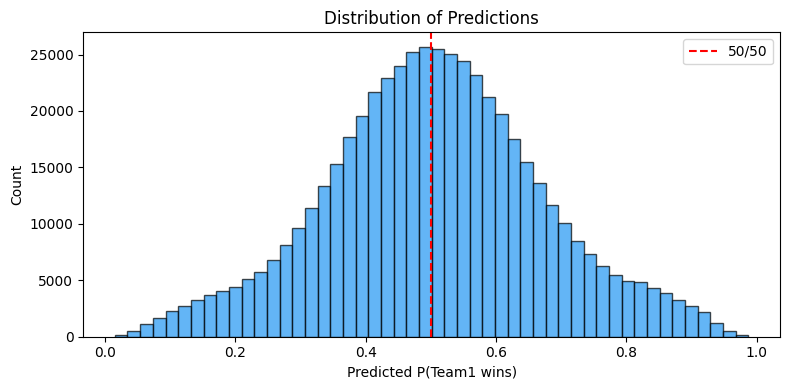

In [57]:
# ── Quick sanity check: distribution of predictions ──
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(sub['Pred'], bins=50, edgecolor='black', alpha=0.7, color='#2196F3')
ax.axvline(0.5, color='red', linestyle='--', label='50/50')
ax.set_xlabel('Predicted P(Team1 wins)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predictions')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from google.adk.agents.parallel_agent import ParallelAgent
from google.adk.agents.loop_agent import LoopAgent

# Parallel feature computation
parallel_features = ParallelAgent(
    name="ParallelFeatures",
    sub_agents=[mens_elo_agent, womens_elo_agent, stats_agent]
)

# Iterative tuning
tuning_loop = LoopAgent(
    name="HyperparamTuner",
    sub_agents=[train_agent, evaluate_agent, adjust_agent],
    max_iterations=5
)